In [1]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing,make_regression
from sklearn.metrics import mean_squared_error,root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# globals

random_state = 42

In [2]:
# Your code here (you may add additional cells if you wish)
n_samples = 20
n_features = 1
noise = 20
bias = 0.5
random_state = 42
coef = True

# Generate the dataset
X, y, coef = make_regression(n_samples=n_samples, n_features=n_features, noise=noise, bias=bias, coef=coef, random_state=random_state)
print("coef", coef)
X

coef 45.606998421703594


array([[ 0.64768854],
       [ 0.49671415],
       [-0.23413696],
       [-1.72491783],
       [-0.90802408],
       [-1.4123037 ],
       [-0.46341769],
       [-1.01283112],
       [-0.23415337],
       [ 0.24196227],
       [-0.46947439],
       [ 1.57921282],
       [ 0.76743473],
       [-0.56228753],
       [ 1.52302986],
       [-1.91328024],
       [ 0.54256004],
       [-0.1382643 ],
       [-0.46572975],
       [ 0.31424733]])

In [3]:
y

array([ 81.22889076,  10.56414237, -20.48699707, -82.75733394,
        14.65400825, -40.03813819, -41.06613388, -70.99456958,
        -7.73464929,   0.86219686, -15.09063755,  60.51807938,
        54.4491909 , -17.35726819,  77.8454807 , -86.86952634,
        12.53334025,   6.14858957, -23.97564386,  36.67172289])

In [9]:
lb = X.min()
ub = X.max()    
a1a = lb,ub    
print(f'a1a = {a1a}')       
a1b = coef 

a1a = (-1.913280244657798, 1.5792128155073915)


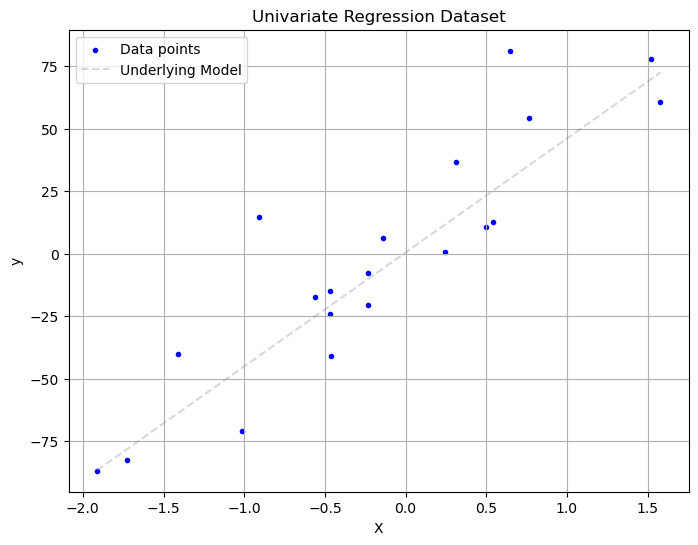

In [11]:
if a1b != 0:        # If you answered the previous questions!

    bias = 0.5

    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue',label="Data points",marker='.')
    plt.plot(a1a,[bias+a1b*a1a[0],bias+a1b*a1a[1]], color="grey", alpha=0.3,label="Underlying Model",linestyle='--')
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("Univariate Regression Dataset")
    plt.legend()
    plt.grid(True)
    plt.show()

In [13]:
# Your answer here, NOT in the next cell (you may add additional cells if you wish)

model = LinearRegression()

model.fit(X, y)

a2a = model.intercept_   # Replace 0 with an expression returning the bias
a2b = model.coef_[0] 
y_pred = model.predict(X)
a2c = mean_squared_error(y, y_pred)   # Replace 0 with an expression returning the training mse
a2d = root_mean_squared_error(y, y_pred)          # Replace 0 with an expression returning the training rmse
a2e = mean_absolute_error(y, y_pred)                # Replace 0 with an expression returning the training mae
a2f = r2_score(y, y_pred)            # Replace 0 with an expression returning the training r2


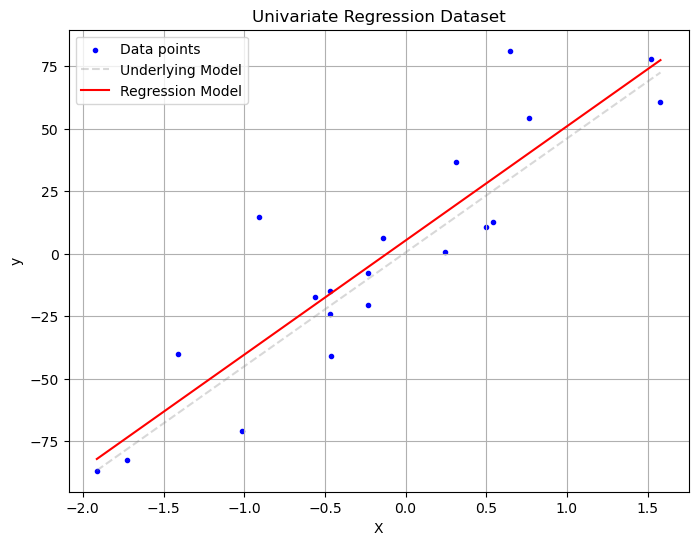

Underlying model = 0.5 + 45.607 * x
Linear model     = 5.2857 + 45.7125 * x
MSE              = 436.9130
R^2              = 0.8072


In [14]:
# Plot the data points and the regression line

if a2d != 0:     # If you answered the previous questions!

    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue',label="Data points",marker='.')
    plt.plot(a1a,[bias+a1b*a1a[0],bias+a1b*a1a[1]], color="grey", alpha=0.3,label="Underlying Model",linestyle='--')
    plt.plot(a1a,[model.intercept_+model.coef_[0]*a1a[0],model.intercept_+model.coef_[0]*a1a[1]], color="red", label="Regression Model")
    
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("Univariate Regression Dataset")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Just some stats
    print(f'Underlying model = {np.around(bias,4)} + {np.around(a1b,4)} * x')
    print(f'Linear model     = {np.around(model.intercept_,4)} + {np.around(model.coef_[0],4)} * x')
    print(f'MSE              = {mean_squared_error(y,y_pred):.4f}')
    print(f'R^2              = {np.around(model.score(X, y),4):.4f}')


The regression line doesn’t match the underlying model for two main reasons:

---

## 1. **Noise in the data**

You generated the data with **`noise=20`**. So the targets are:

- **Underlying model:** (y = bias + slope * x)
- **What you actually have:** (y = bias + slope * x + random error) (with that error having standard deviation 20)

The fitted line is estimated from these **noisy** \((X, y)\) points. It minimizes mean squared error on *this* sample, not on the “true” line. So the best line for the noisy data is not the same as the true line—it’s pulled toward the noise.

---

## 2. **Small sample size**

With **`n_samples=20`**, you only have 20 points. The estimated intercept and slope are random: they vary from sample to sample. So even if there were less noise, the fitted line would only *on average* match the underlying model; for any single small sample it will usually be off a bit. With both noise and small \(n\), the mismatch is more visible.

---

## Summary

- **Underlying model** = the true line used to generate the data (bias + slope · \(x\)).
- **Fitted regression line** = the line that best fits the **noisy** \((X, y)\) you actually observed.

Because of **noise** and **finite sample size**, the fitted line is an *estimate* of the true line and won’t match it exactly. If you reduced `noise` or increased `n_samples`, the fitted line would usually get closer to the underlying model.

Yes. Both **n_samples** and **noise** affect how close the fitted regression line is to the underlying model.

---

## How they affect the fit

**n_samples (sample size)**  
- **Larger n:** More data averages out the noise, so the fitted slope and intercept get closer to the true values (less sampling variability).  
- **Smaller n:** A few noisy points can pull the line a lot, so the fit can differ more from the underlying model.

**noise (standard deviation of the errors)**  
- **Lower noise:** Points sit closer to the true line, so the fitted line tracks the underlying model better.  
- **Higher noise:** Points are more scattered, so the best-fit line is more influenced by the noise and can differ more from the true line.

---

## In your setup

You used **n_samples=20** and **noise=20**. So you have a small sample and relatively strong noise, which is why the fitted line doesn’t match the underlying model very closely.

If you want to see the effect yourself, you can try in the notebook (or in a scratch cell):

- Increase **n_samples** (e.g. 200 or 2000) with the same noise → fitted line usually gets closer to the true line.  
- Decrease **noise** (e.g. 2 or 5) with the same n_samples → same idea.

So your statement is correct: both n_samples and noise impact how well the regression model matches the actual (underlying) model.

In [16]:
def generate_new_data_points(lb, ub, slope, bias, noise):
    x = np.random.uniform(lb, ub)
    y = bias + slope * x + np.random.normal(0, noise)
    return x, y

X_new = [generate_new_data_points(lb, ub, a1b, bias, noise) for _ in range(5)]
print("X_new", X_new)
X_new = np.array(X_new)
print("X_new Array", X_new)
X_new = X_new.T
print("X_new Transpose", X_new)

X_new [(0.6849166767900257, 5.557261646749684), (-0.08466557531666963, 0.5671180936196141), (0.8538038663575414, 38.315348154295286), (-0.3936145422429864, -21.935901284216747), (-0.7499668023648902, -34.91707484696523)]
X_new Array [[  0.68491668   5.55726165]
 [ -0.08466558   0.56711809]
 [  0.85380387  38.31534815]
 [ -0.39361454 -21.93590128]
 [ -0.7499668  -34.91707485]]
X_new Transpose [[  0.68491668  -0.08466558   0.85380387  -0.39361454  -0.7499668 ]
 [  5.55726165   0.56711809  38.31534815 -21.93590128 -34.91707485]]
